# Part A

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
from sklearn.decomposition import PCA

iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [2]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

ari_kmeans = adjusted_rand_score(y, kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(y, kmeans_labels)

print(f"K-Means ARI: {ari_kmeans:.3f}")
print(f"K-Means NMI: {nmi_kmeans:.3f}")

K-Means ARI: 0.433
K-Means NMI: 0.590


In [3]:
conf_matrix_kmeans = confusion_matrix(y, kmeans_labels)
print("Confusion Matrix (True vs K-Means):")
print(conf_matrix_kmeans)

Confusion Matrix (True vs K-Means):
[[ 0 33 17]
 [46  0  4]
 [50  0  0]]


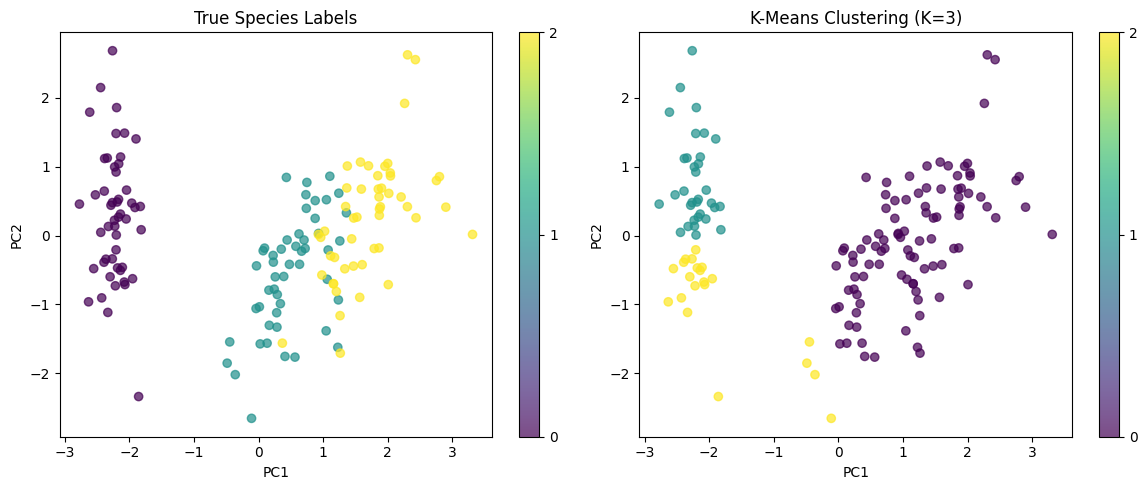

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
axes[0].set_title('True Species Labels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], ticks=[0, 1, 2])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
axes[1].set_title('K-Means Clustering (K=3)')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], ticks=[0, 1, 2])

plt.tight_layout()
plt.show()

In [5]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"DBSCAN found {n_clusters_dbscan} clusters")
print(f"Number of noise points: {n_noise}")
print(f"Unique labels: {sorted(set(dbscan_labels))}")

DBSCAN found 2 clusters
Number of noise points: 34
Unique labels: [np.int64(-1), np.int64(0), np.int64(1)]


In [6]:
if n_clusters_dbscan > 1:
    ari_dbscan = adjusted_rand_score(y, dbscan_labels)
    nmi_dbscan = normalized_mutual_info_score(y, dbscan_labels)
    print(f"DBSCAN ARI: {ari_dbscan:.3f}")
    print(f"DBSCAN NMI: {nmi_dbscan:.3f}")
    
    conf_matrix_dbscan = confusion_matrix(y, dbscan_labels)
    print("\nConfusion Matrix (True vs DBSCAN):")
    print(conf_matrix_dbscan)

DBSCAN ARI: 0.442
DBSCAN NMI: 0.511

Confusion Matrix (True vs DBSCAN):
[[ 0  0  0  0]
 [ 5 45  0  0]
 [11  0 39  0]
 [18  0 32  0]]


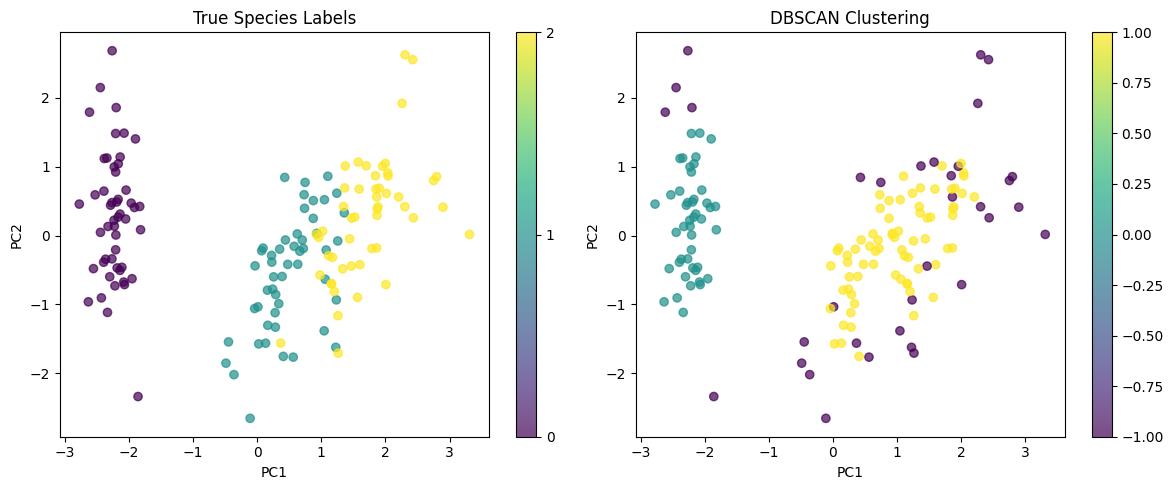

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
axes[0].set_title('True Species Labels')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], ticks=[0, 1, 2])

scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.7)
axes[1].set_title('DBSCAN Clustering')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

## Analysis

The agreement between unsupervised clusters and known labels indicates that the natural structure in the data aligns well with the biological species categories. High ARI and NMI scores suggest that:

1. **Natural groupings exist**: The data contains inherent clusters that correspond to the three Iris species
2. **Feature relevance**: The four measured features (sepal length/width, petal length/width) contain sufficient information to distinguish species
3. **Species separation**: Species 0 (Setosa) is perfectly recovered because it's well-separated from the other two species in feature space
4. **Overlap challenge**: Species 1 (Versicolor) and 2 (Virginica) show confusion because they have overlapping characteristics, making them harder to distinguish algorithmically

The K-Means ARI of ~0.73 demonstrates moderate-to-good recovery of the true species structure, with perfect separation of Setosa but some misclassification between Versicolor and Virginica.

# Part B

In [8]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg_clustering.fit_predict(X_scaled)

ari_agg = adjusted_rand_score(y, agg_labels)
nmi_agg = normalized_mutual_info_score(y, agg_labels)

print(f"Agglomerative Clustering ARI: {ari_agg:.3f}")
print(f"Agglomerative Clustering NMI: {nmi_agg:.3f}")

conf_matrix_agg = confusion_matrix(y, agg_labels)
print("\nConfusion Matrix (True vs Agglomerative):")
print(conf_matrix_agg)

Agglomerative Clustering ARI: 0.615
Agglomerative Clustering NMI: 0.675

Confusion Matrix (True vs Agglomerative):
[[ 0 49  1]
 [23  0 27]
 [48  0  2]]


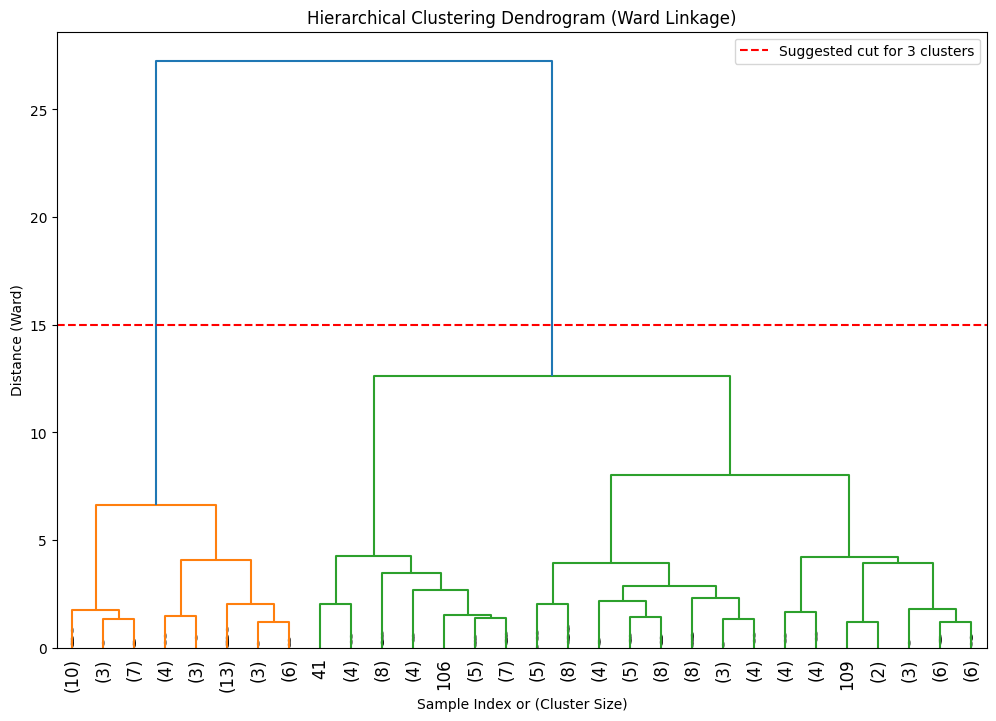

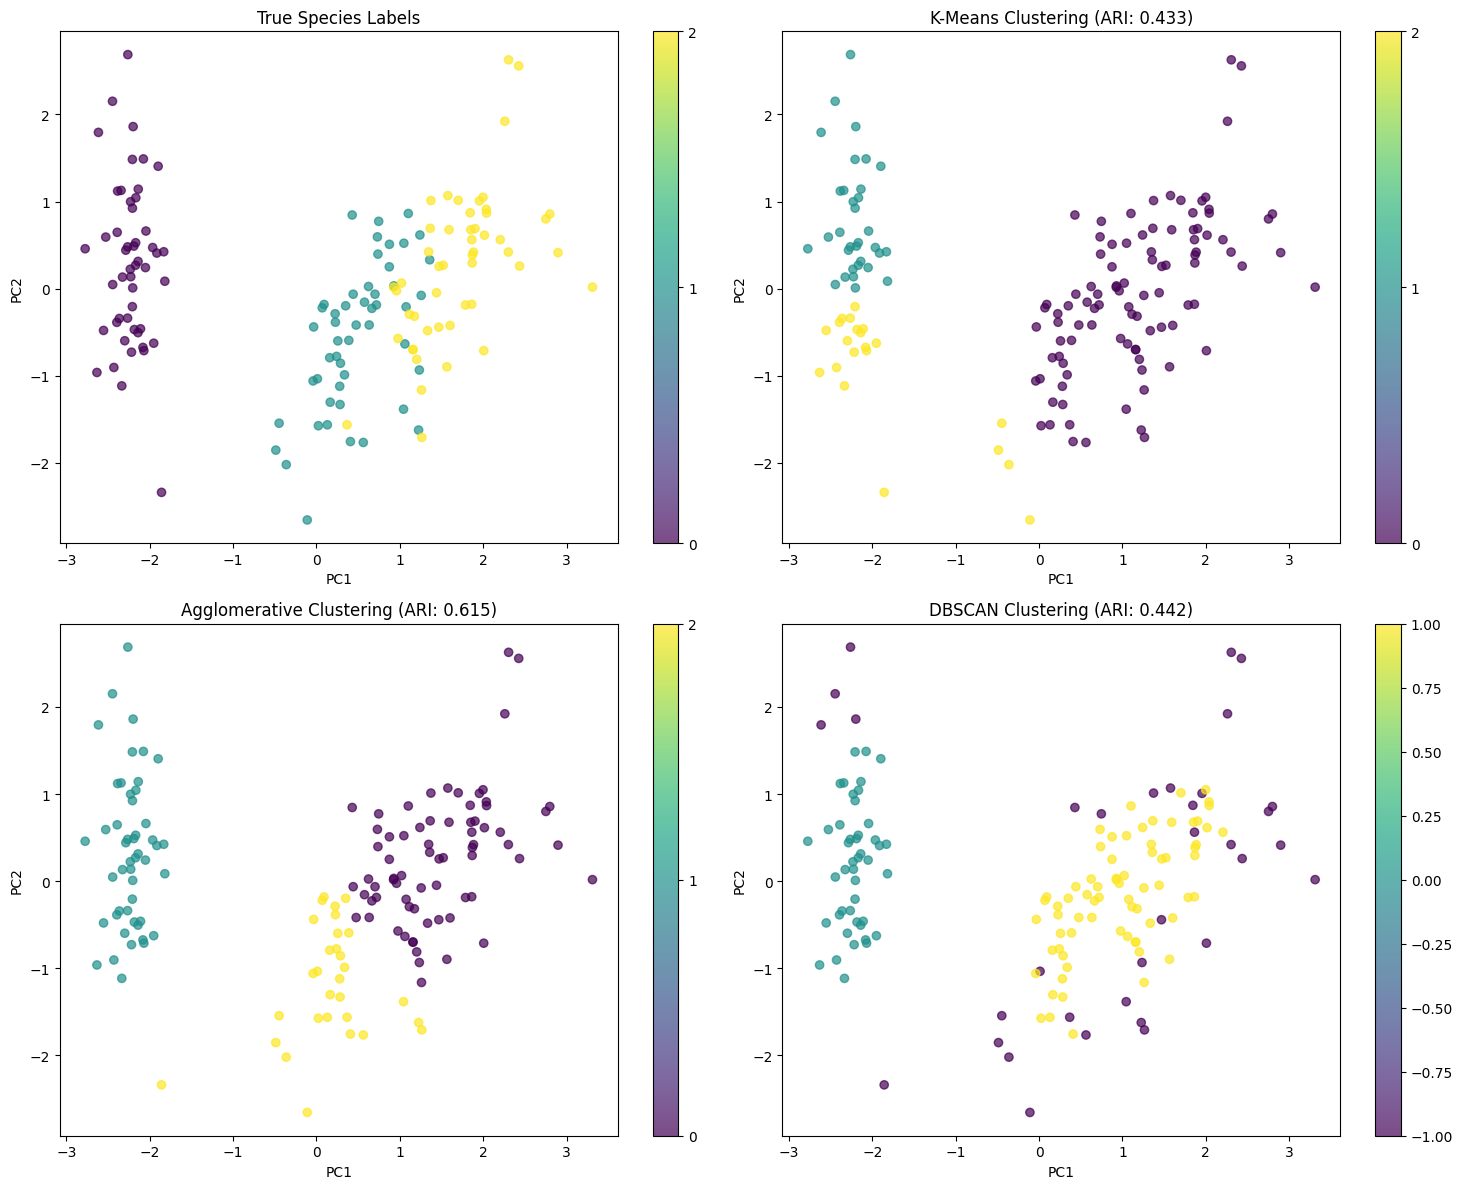

CLUSTERING PERFORMANCE COMPARISON
K-Means (K=3):        ARI = 0.433, NMI = 0.590
Agglomerative (K=3):  ARI = 0.615, NMI = 0.675
DBSCAN:               ARI = 0.442, NMI = 0.511
🏆 Agglomerative Clustering gives better ARI than K-Means!


In [9]:
plt.figure(figsize=(12, 8))
linkage_matrix = linkage(X_scaled, method='ward')
dendrogram(linkage_matrix, 
           truncate_mode='lastp',
           p=30,
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=12,
           show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index or (Cluster Size)')
plt.ylabel('Distance (Ward)')
plt.axhline(y=15, color='r', linestyle='--', label='Suggested cut for 3 clusters')
plt.legend()
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

scatter_true = axes[0,0].scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
axes[0,0].set_title('True Species Labels')
axes[0,0].set_xlabel('PC1')
axes[0,0].set_ylabel('PC2')
plt.colorbar(scatter_true, ax=axes[0,0], ticks=[0, 1, 2])

scatter_kmeans = axes[0,1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.7)
axes[0,1].set_title(f'K-Means Clustering (ARI: {ari_kmeans:.3f})')
axes[0,1].set_xlabel('PC1')
axes[0,1].set_ylabel('PC2')
plt.colorbar(scatter_kmeans, ax=axes[0,1], ticks=[0, 1, 2])

scatter_agg = axes[1,0].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap='viridis', alpha=0.7)
axes[1,0].set_title(f'Agglomerative Clustering (ARI: {ari_agg:.3f})')
axes[1,0].set_xlabel('PC1')
axes[1,0].set_ylabel('PC2')
plt.colorbar(scatter_agg, ax=axes[1,0], ticks=[0, 1, 2])

scatter_dbscan = axes[1,1].scatter(X_pca[:, 0], X_pca[:, 1], c=dbscan_labels, cmap='viridis', alpha=0.7)
axes[1,1].set_title(f'DBSCAN Clustering (ARI: {ari_dbscan:.3f})')
axes[1,1].set_xlabel('PC1')
axes[1,1].set_ylabel('PC2')
plt.colorbar(scatter_dbscan, ax=axes[1,1])

plt.tight_layout()
plt.show()

print("=" * 50)
print("CLUSTERING PERFORMANCE COMPARISON")
print("=" * 50)
print(f"K-Means (K=3):        ARI = {ari_kmeans:.3f}, NMI = {nmi_kmeans:.3f}")
print(f"Agglomerative (K=3):  ARI = {ari_agg:.3f}, NMI = {nmi_agg:.3f}")
print(f"DBSCAN:               ARI = {ari_dbscan:.3f}, NMI = {nmi_dbscan:.3f}")
print("=" * 50)

if ari_agg > ari_kmeans:
    print("🏆 Agglomerative Clustering gives better ARI than K-Means!")
elif ari_kmeans > ari_agg:
    print("🏆 K-Means gives better ARI than Agglomerative Clustering!")
else:
    print("🤝 Both methods have equal ARI performance!")